# Groundwater Quality Risk Assessment System

## Exploratory Data Analysis (EDA)

### Objectives

- Understand the dataset
- Examine feature distributions
- Identify missing values
- Detect duplicates
- Analyze target variables
- Identify preprocessing requirements

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/raw/ground_water_quality_2018_2020_unified.csv")

df.head()

,year,sno,district,mandal,village,lat_gis,long_gis,gwl,season,pH,EC,TDS,CO3,HCO3,Cl,F,NO3,SO4,Na,K,Ca,Mg,TH,SAR,RSC_meq_L,Classification,Classification_drinking
0,2018,1,ADILABAD,Adilabad,Adilabad,19.668300,78.524700,5.09,postmonsoon 2018,8.28,745,476.80,0.0,220.0,60,0.44,42.276818,46.0,49.0,4.0,48.0,38.896,279.934211,1.273328,-1.198684,C2S1,P.S.
1,2018,2,ADILABAD,Bazarhatnur,Bazarhatnur,19.458888,78.350833,5.10,postmonsoon 2018,8.29,921,589.44,0.0,230.0,80,0.56,100.659091,68.0,42.0,5.0,56.0,63.206,399.893092,0.913166,-3.397862,C3S1,P.S.
2,2018,3,ADILABAD,Gudihatnoor,Gudihatnoor,19.525555,78.512222,4.98,postmonsoon 2018,7.69,510,326.40,0.0,200.0,30,0.66,41.471545,44.0,45.0,2.0,24.0,38.896,219.934211,1.319284,-0.398684,C2S1,P.S.
3,2018,4,ADILABAD,Jainath,Jainath,19.730555,78.640000,5.75,postmonsoon 2018,8.09,422,270.08,0.0,160.0,10,0.58,10.669864,35.0,27.0,1.0,32.0,19.448,159.967105,0.928155,0.000658,C2S1,P.S.
4,2018,5,ADILABAD,Narnoor,Narnoor,19.495665,78.852654,2.15,postmonsoon 2018,8.21,2321,1485.44,0.0,300.0,340,2.56,128.843636,280.0,298.0,5.0,56.0,92.378,519.843750,5.682664,-4.396875,C4S2,P.S.


In [3]:
df.shape

(1106, 27)

In [4]:
df.columns

Index(['year', 'sno', 'district', 'mandal', 'village', 'lat_gis', 'long_gis',
       'gwl', 'season', 'pH', 'EC', 'TDS', 'CO3', 'HCO3', 'Cl', 'F', 'NO3',
       'SO4', 'Na', 'K', 'Ca', 'Mg', 'TH', 'SAR', 'RSC_meq_L',
       'Classification', 'Classification_drinking'],
      dtype='str')

In [5]:
df.dtypes

year                         int64
sno                          int64
district                       str
mandal                         str
village                        str
lat_gis                    float64
long_gis                   float64
gwl                        float64
season                         str
pH                             str
EC                           int64
TDS                        float64
CO3                        float64
HCO3                       float64
Cl                           int64
F                          float64
NO3                        float64
SO4                        float64
Na                         float64
K                          float64
Ca                         float64
Mg                         float64
TH                         float64
SAR                        float64
RSC_meq_L                  float64
Classification                 str
Classification_drinking        str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1106 entries, 0 to 1105
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   year                     1106 non-null   int64  
 1   sno                      1106 non-null   int64  
 2   district                 1106 non-null   str    
 3   mandal                   1106 non-null   str    
 4   village                  1106 non-null   str    
 5   lat_gis                  1106 non-null   float64
 6   long_gis                 1106 non-null   float64
 7   gwl                      1095 non-null   float64
 8   season                   1106 non-null   str    
 9   pH                       1106 non-null   str    
 10  EC                       1106 non-null   int64  
 11  TDS                      1106 non-null   float64
 12  CO3                      946 non-null    float64
 13  HCO3                     1106 non-null   float64
 14  Cl                       1106 non-n

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,1106.0,2018.994575,0.819429,2018.000000,2018.000000,2019.000000,2020.000000,2020.000000
sno,1106.0,189.420434,110.031182,1.000000,94.000000,188.500000,285.000000,379.000000
lat_gis,1106.0,17.708504,0.852864,15.896441,17.136028,17.639128,18.359652,19.730555
long_gis,1106.0,78.790897,0.818382,77.444000,78.184623,78.579444,79.351937,80.920000
gwl,1095.0,8.590411,7.525315,0.170000,3.060000,5.930000,12.380000,43.170000
EC,1106.0,1362.238698,861.061139,205.000000,782.000000,1179.500000,1673.500000,9499.000000
TDS,1106.0,871.832767,551.079129,131.200000,500.480000,754.880000,1071.040000,6079.360000
CO3,946.0,6.822446,17.217132,0.000000,0.000000,0.000000,0.000000,100.000000
HCO3,1106.0,300.751525,135.121572,30.000000,200.000000,290.000000,380.000000,1070.000000
Cl,1106.0,194.258590,200.599198,10.000000,60.000000,130.000000,260.000000,2480.000000


In [8]:
df.isnull().sum()

year                         0
sno                          0
district                     0
mandal                       0
village                      0
lat_gis                      0
long_gis                     0
gwl                         11
season                       0
pH                           0
EC                           0
TDS                          0
CO3                        160
HCO3                         0
Cl                           0
F                            0
NO3                          0
SO4                          0
Na                           0
K                            0
Ca                           0
Mg                           0
TH                           0
SAR                          0
RSC_meq_L                    0
Classification               0
Classification_drinking      0
dtype: int64

In [9]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

CO3                        14.466546
gwl                         0.994575
sno                         0.000000
district                    0.000000
mandal                      0.000000
lat_gis                     0.000000
village                     0.000000
long_gis                    0.000000
season                      0.000000
pH                          0.000000
year                        0.000000
EC                          0.000000
TDS                         0.000000
HCO3                        0.000000
Cl                          0.000000
F                           0.000000
NO3                         0.000000
SO4                         0.000000
Na                          0.000000
K                           0.000000
Ca                          0.000000
Mg                          0.000000
TH                          0.000000
SAR                         0.000000
RSC_meq_L                   0.000000
Classification              0.000000
Classification_drinking     0.000000
d

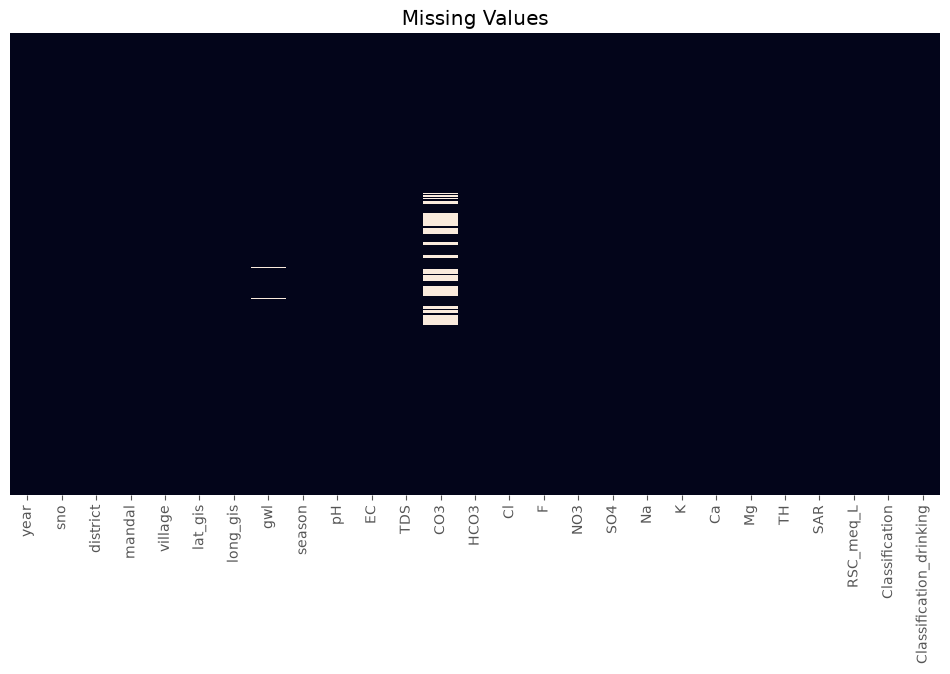

In [10]:
plt.figure(figsize=(12,6))

sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False)

plt.title("Missing Values")
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["Classification"].value_counts()

Classification
C3S1    696
C2S1    248
C4S1     87
C4S2     36
C3S2     12
C4S4      7
C3S3      6
C4S3      5
C1S1      3
OG        2
O.G       2
C3S4      1
C2S2      1
Name: count, dtype: int64

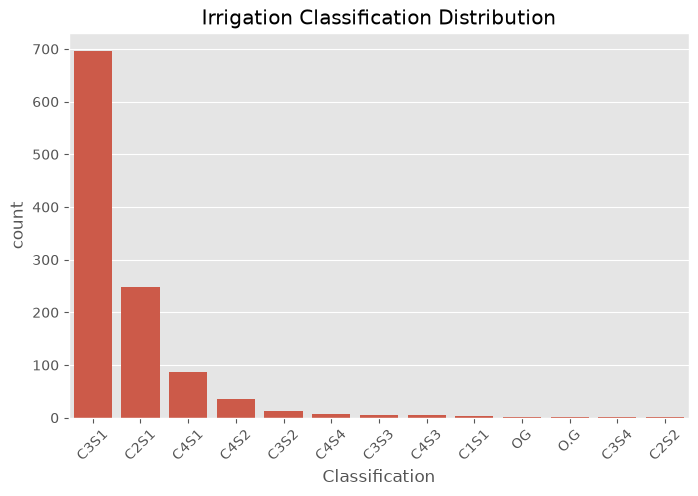

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Classification",
    order=df["Classification"].value_counts().index
)

plt.xticks(rotation=45)

plt.title("Irrigation Classification Distribution")

plt.show()

In [14]:
numerical = df.select_dtypes(include=np.number)

numerical.columns

Index(['year', 'sno', 'lat_gis', 'long_gis', 'gwl', 'EC', 'TDS', 'CO3', 'HCO3',
       'Cl', 'F', 'NO3', 'SO4', 'Na', 'K', 'Ca', 'Mg', 'TH', 'SAR',
       'RSC_meq_L'],
      dtype='str')

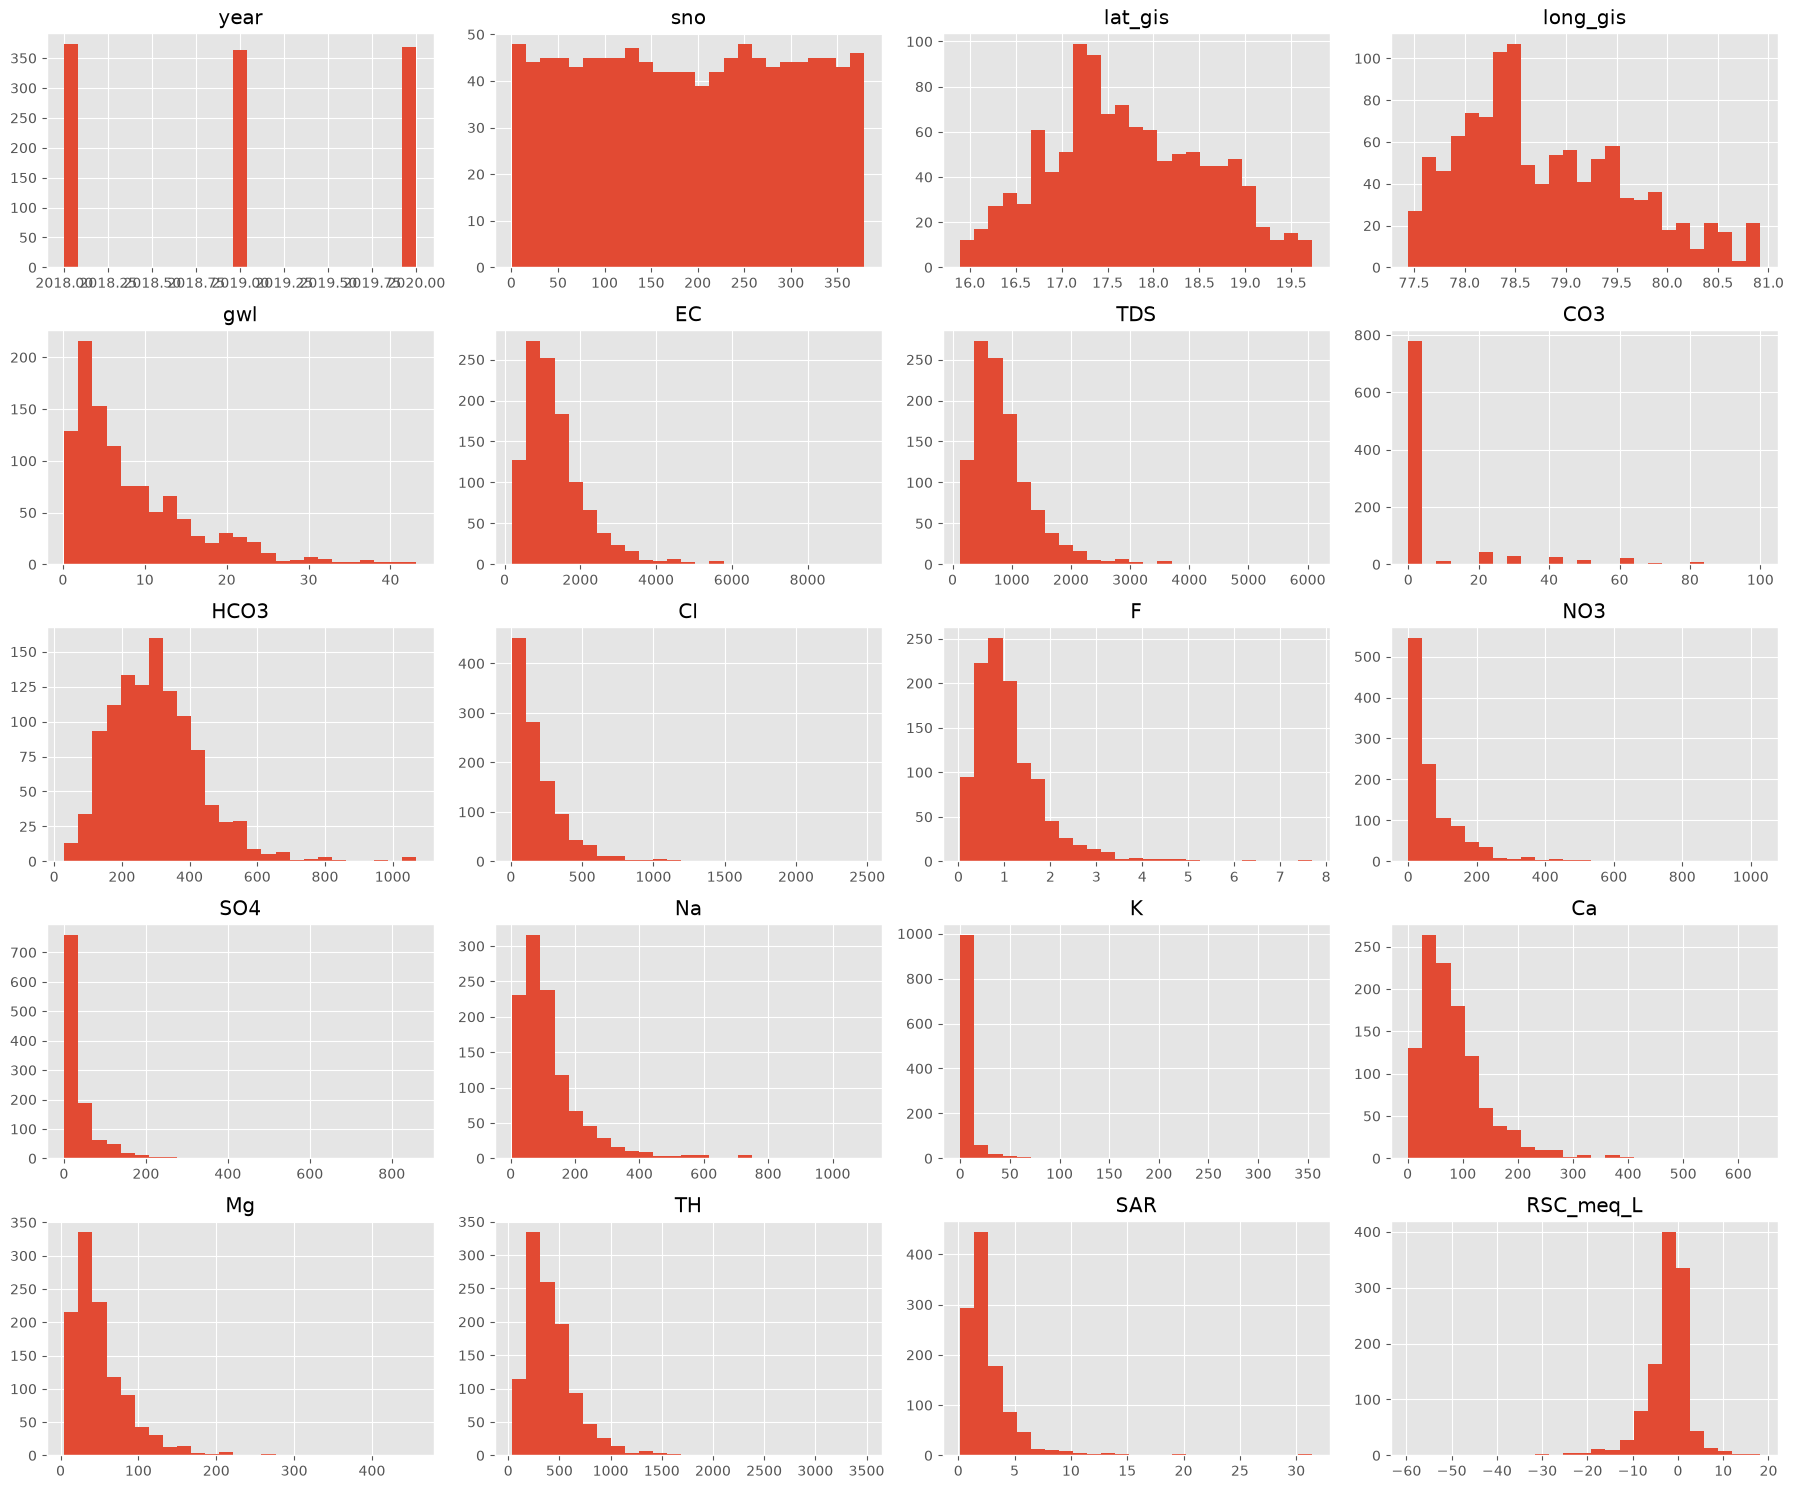

In [15]:
numerical.hist(
    figsize=(18,15),
    bins=25
)

plt.tight_layout()

plt.show()

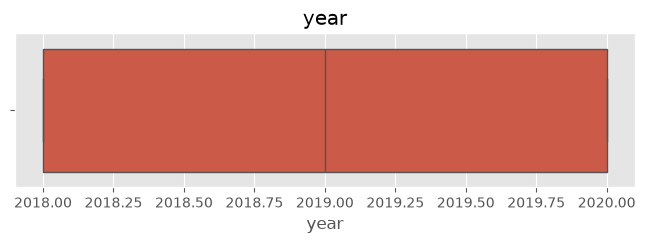

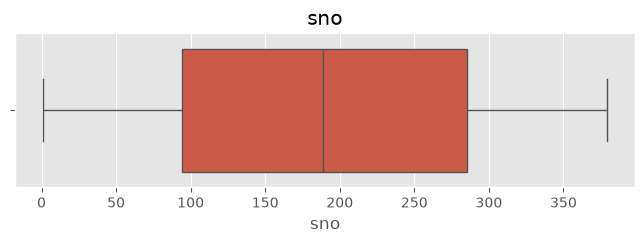

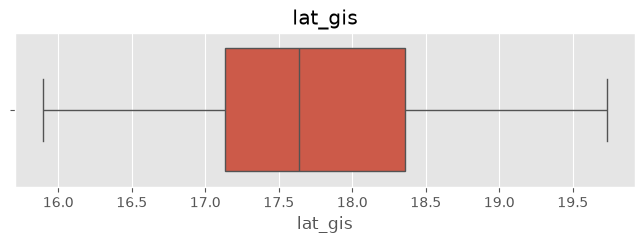

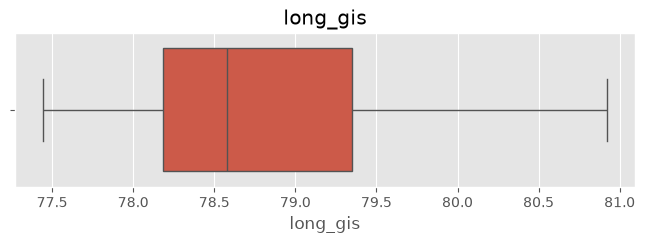

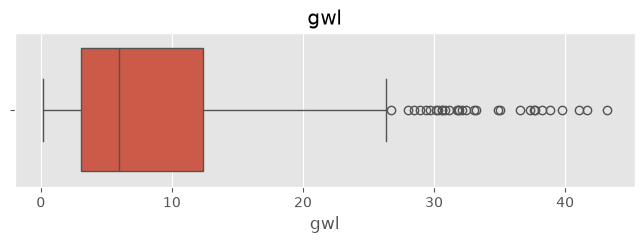

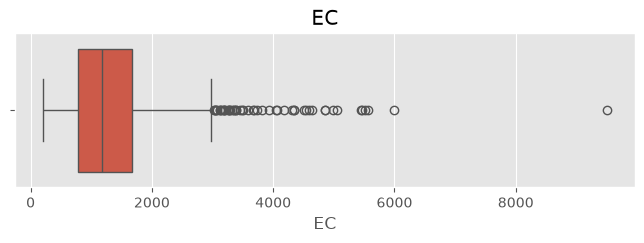

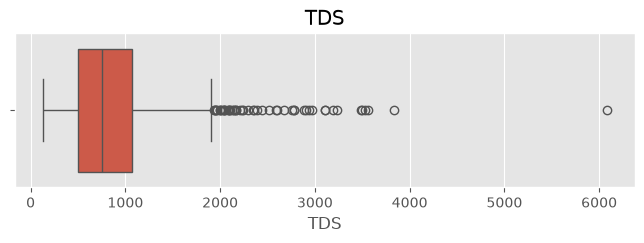

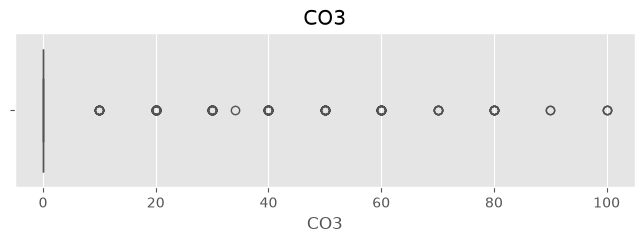

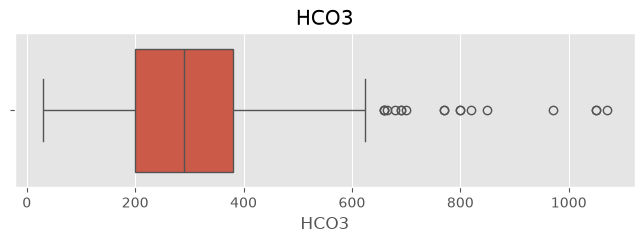

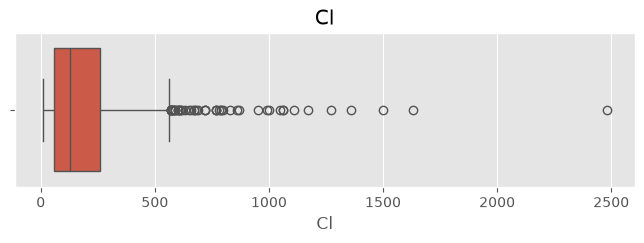

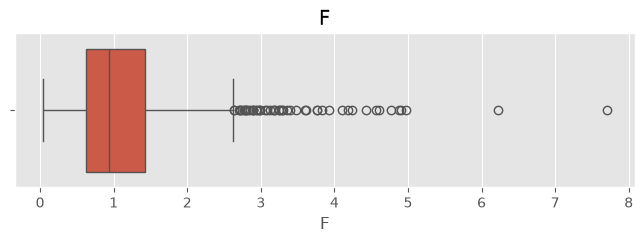

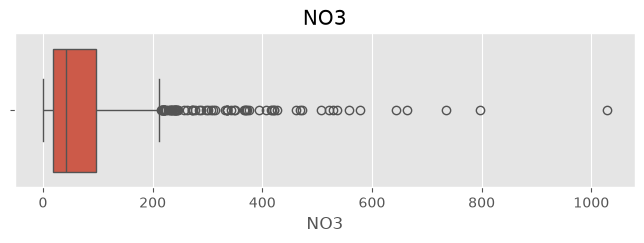

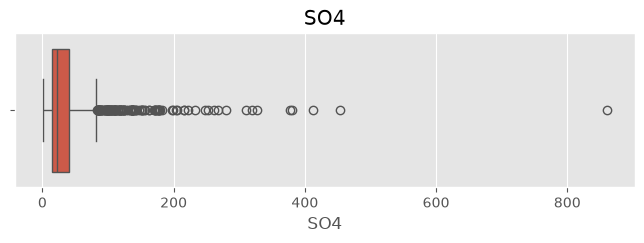

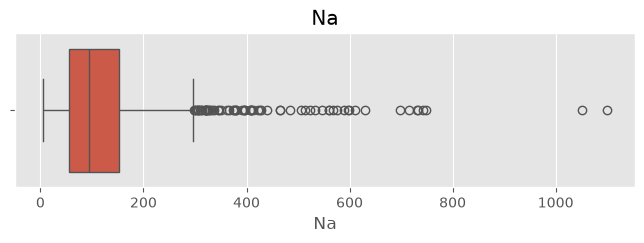

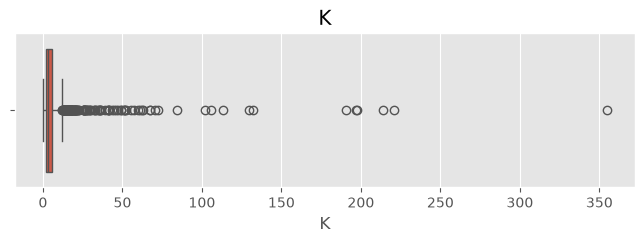

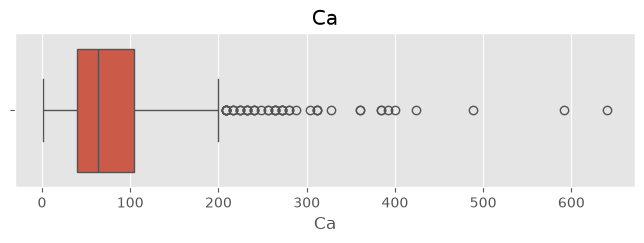

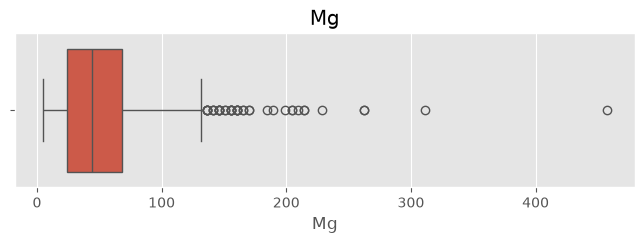

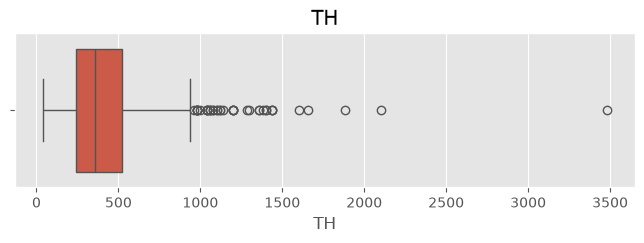

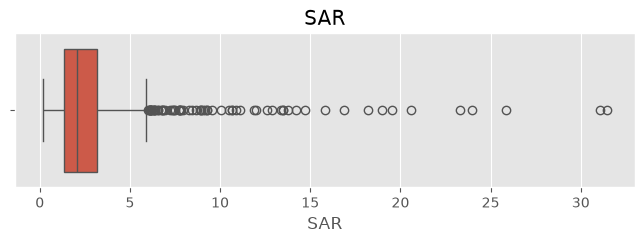

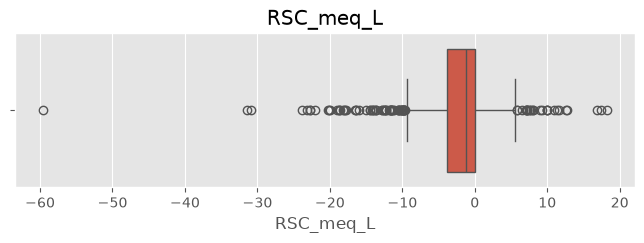

In [16]:
for col in numerical.columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

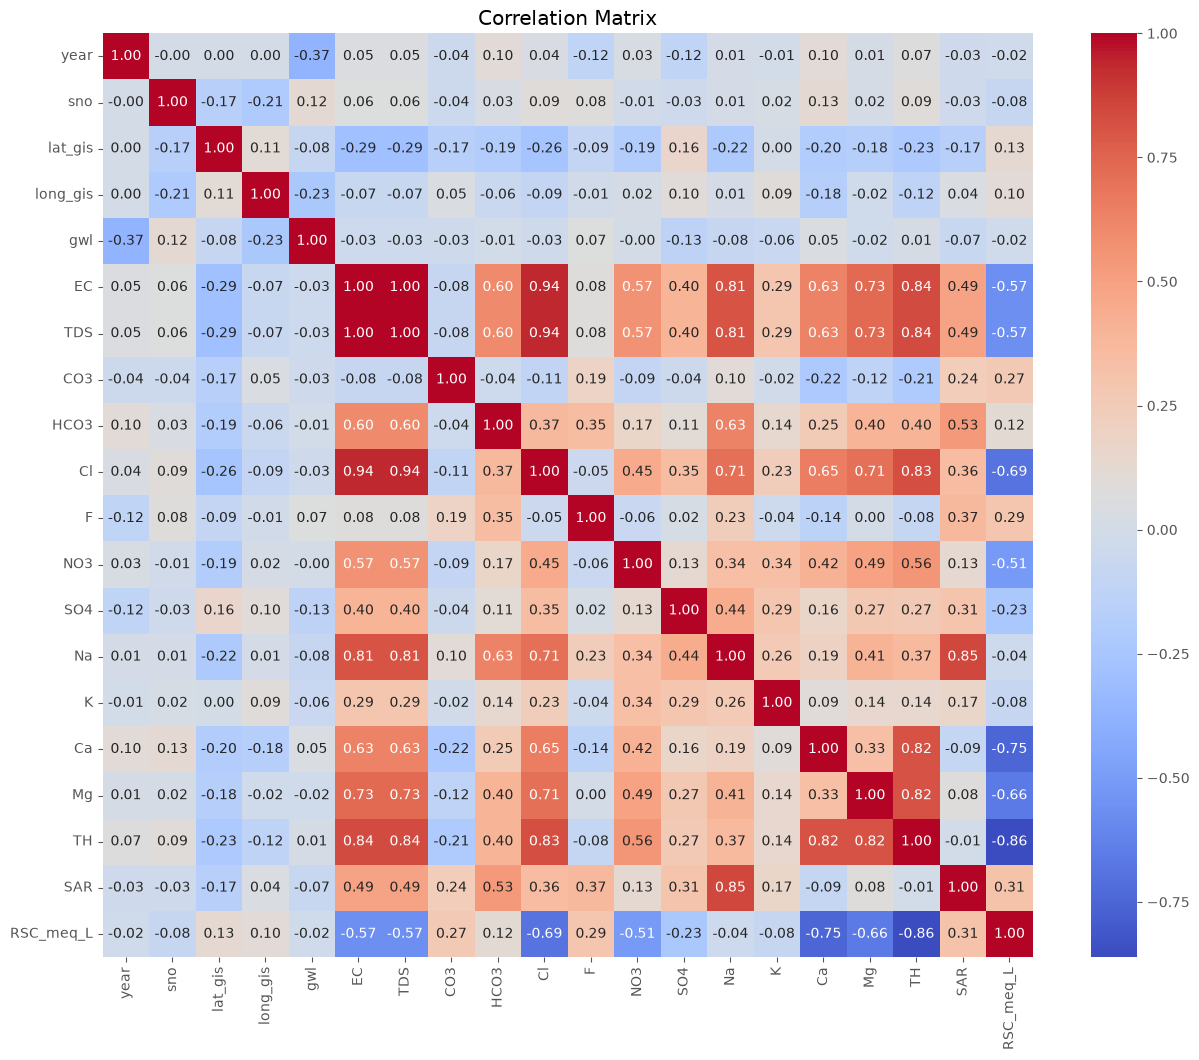

In [17]:
corr = numerical.corr()

plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [18]:
features = [
    "EC",
    "TDS",
    "SAR",
    "Na",
    "Ca",
    "Mg"
]

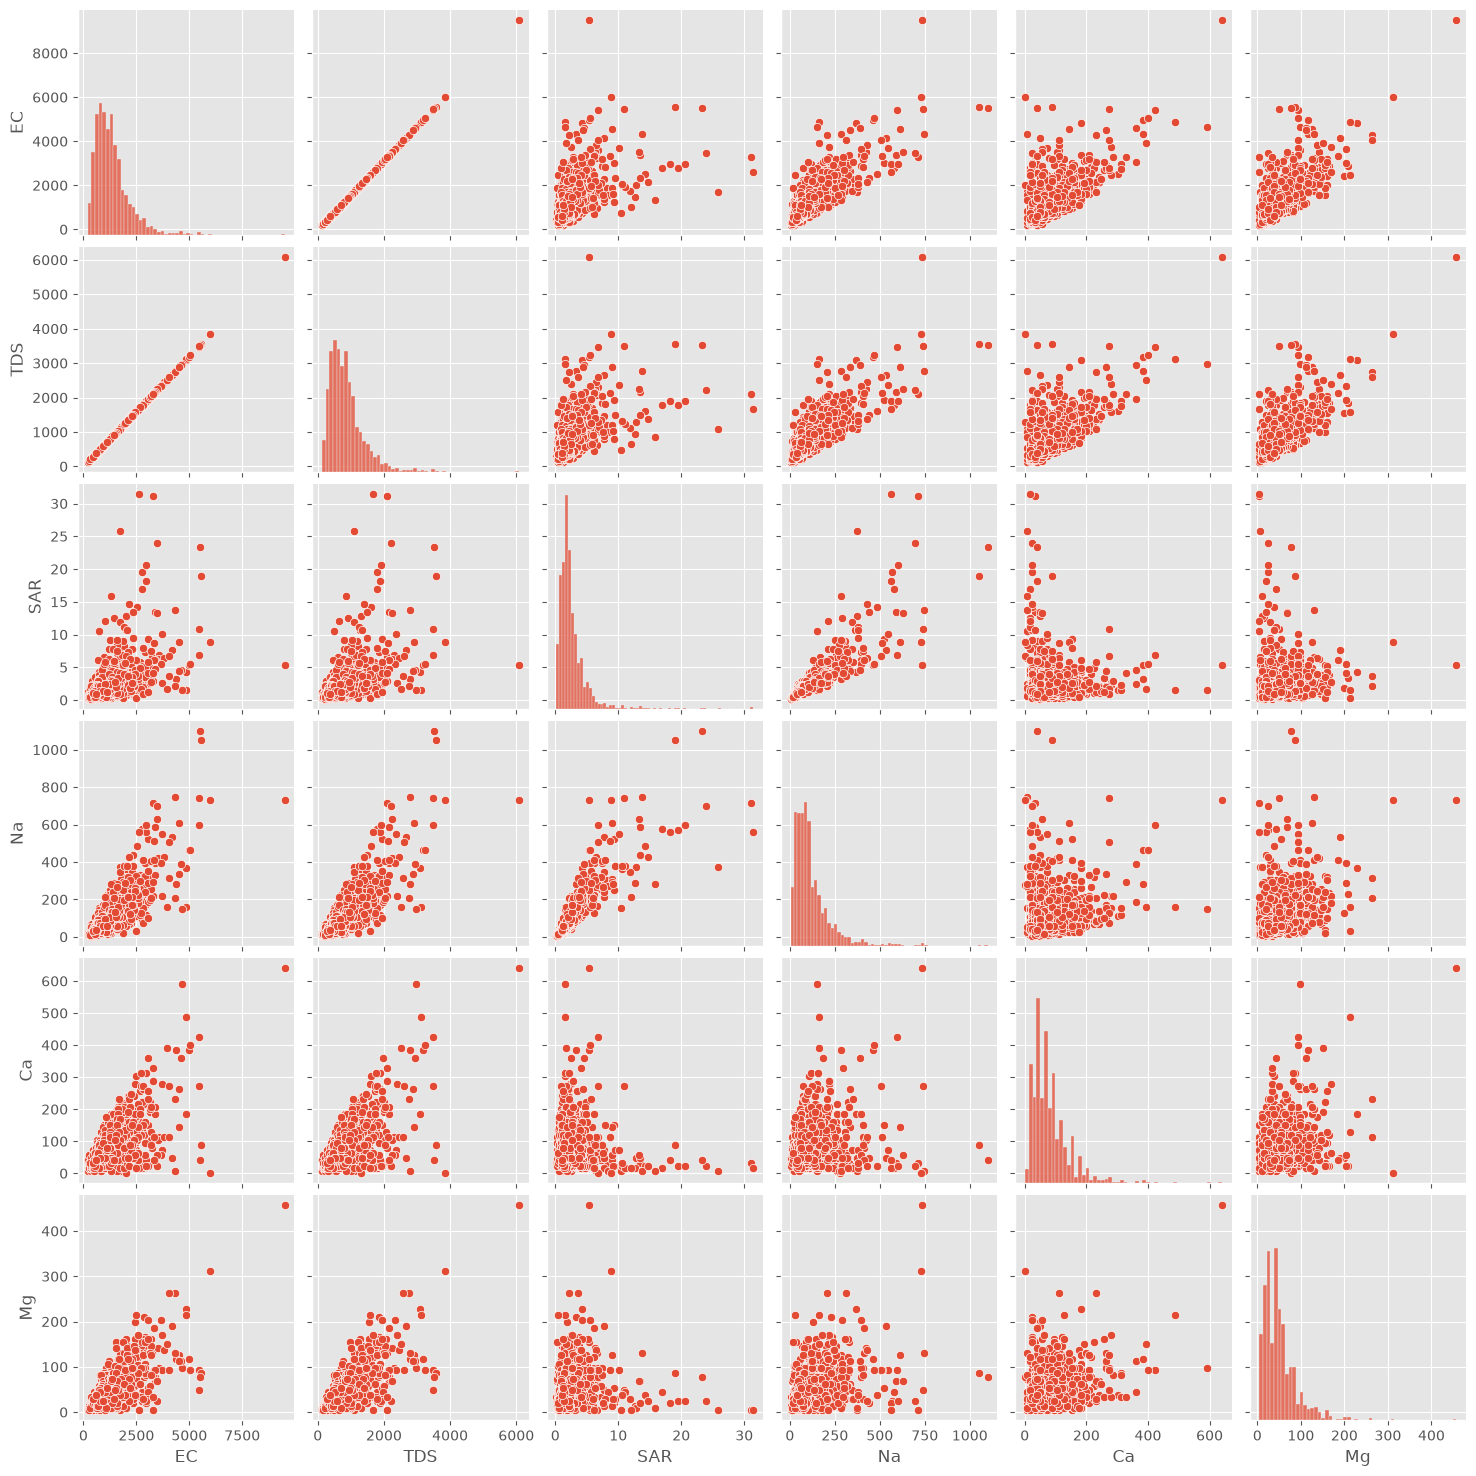

In [19]:
sns.pairplot(
    df[features]
)

plt.show()

<Axes: xlabel='Classification', ylabel='EC'>

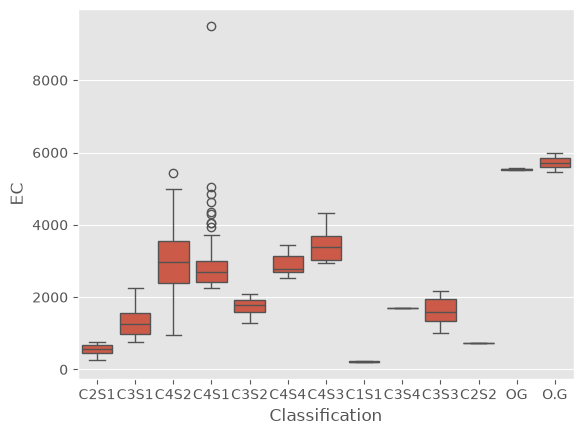

In [20]:
sns.boxplot(
    data=df,
    x="Classification",
    y="EC"
)

EDA Summary

• Dataset contains 1,106 groundwater samples (2018–2020), with 27 features covering location, chemical parameters, and irrigation/drinking classifications.
• No duplicate observations.
• Missing values exist in CO3 (~14.5%) and gwl (~1%).
• EC and TDS have a strong positive correlation (expected, since TDS is derived from conductivity).
• Several chemical features (e.g., EC, Cl, NO3, SAR) contain extreme outliers, visible in the boxplots.
• Target classes (Classification) are heavily imbalanced — C3S1 alone accounts for ~63% of samples, while several classes have fewer than 5 samples.
• Numerical features vary widely in scale and will require scaling before modeling.
• Missing values will require imputation, particularly for CO3.
• Label encoding is required for irrigation classes, and label inconsistencies (e.g., "OG" vs "O.G") need to be standardized first.
• pH is currently stored as a string and should be converted to numeric type during preprocessing.
• Dataset appears suitable for supervised learning, though the class imbalance will need to be addressed (e.g., resampling, class weighting, or merging rare classes).